In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import arviz as az
import blackjax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx
from jax.scipy import stats
from tensorflow_probability.substrates.jax import distributions
from confrdm_jax.flows import evaluate_pdf_sf
from confrdm_jax.flows import load_conditioner
from confrdm_jax.flows import make_mlp_conditioner
from confrdm_jax.mcmc import warmup, inference_loop_multiple_chains
from confrdm_jax.likelihoods import create_crdm_two_accumulators_likelihood_conditions, create_crdm_two_accumulators_likelihood
from confrdm_jax.simulators import create_crdm_single_prior_informed
from confrdm_jax.simulators import sample_conditional_crdm_single

In [2]:
prior = create_crdm_single_prior_informed()

In [3]:
master_key = jax.random.key(2025)
conditioner_key, test_key = jax.random.split(master_key)

rngs = nnx.Rngs(default=conditioner_key)

# conditioner = make_mlp_conditioner(num_in=5, num_bins=4, rngs=rngs)
conditioner = load_conditioner(make_mlp_conditioner(num_in=5, num_bins=4, num_mid=64, rngs=rngs), Path("../outputs/crdm/train_steps=1000/conditioner").absolute())
conditioner.eval()

In [4]:
test_data, test_context = sample_conditional_crdm_single(test_key, (1, 100), prior, 0.001, 4.0)

test_pdf, test_sf = evaluate_pdf_sf(conditioner, test_data.squeeze(), test_context.squeeze())

Text(0.5, 0, 'RT (in s)')

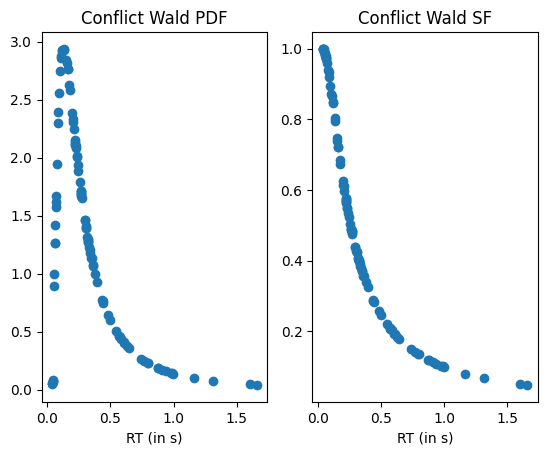

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.plot(test_data.squeeze(), jnp.exp(test_pdf), "o", label="Approx")

ax1.set_xlabel("RT (in s)")
ax1.set_title("Conflict Wald PDF")
ax2.plot(test_data.squeeze(), jnp.exp(test_sf), "o", label="Approx")

ax2.set_title("Conflict Wald SF")
ax2.set_xlabel("RT (in s)")

In [6]:
test_data.squeeze()[jnp.exp(test_pdf) > 50]

Array([], shape=(0,), dtype=float32)

In [7]:
def crdm_log_pdf_sf(rt, v_c, amp, tau, s, b, t0):
    rt = rt - t0
    rt = jnp.maximum(0.0, rt)

    return evaluate_pdf_sf(conditioner, rt, jnp.array([v_c, jnp.abs(amp), tau, s, b]))

# @jax.jit
def inv_gauss_log_pdf_sf(rt, v, s, b, t0):
    rt = rt - t0
    rt = jnp.maximum(0.0, rt)
    # mu_winner = b/drift_winner
    mu = b / v
    # lam_winner = (b/s_winner)**2
    lam = (b / s)**2

    dist = distributions.InverseGaussian(mu, lam)

    return dist.log_prob(rt), dist.log_survival_function(rt)


def _create_crdm_two_accumulators_likelihood_congruent(data):
    rt = data[:, 0]
    choice = data[:, 1]

    # @nnx.jit
    def likelihood_fun(x):

        v_c_true = x[0] + x[1]
        v_c_false = x[0]
        amp = x[2]
        tau = x[3]
        s_true = x[4]
        s_false = 1.0
        b = x[5]
        t0 = x[6]

        log_pdf_true, log_sf_true = crdm_log_pdf_sf(rt, v_c_true, amp, tau, s_true, b, t0)
        log_pdf_false, log_sf_false = inv_gauss_log_pdf_sf(rt, v_c_false, s_false, b, t0)

        dens_true = log_pdf_true.squeeze() + log_sf_false.squeeze()
        dens_false = log_pdf_false.squeeze() + log_sf_true.squeeze()

        ll = jnp.where(choice == 1, dens_true, dens_false)

        return jnp.where(jnp.isfinite(ll), ll, jnp.log(1e-12))

    return likelihood_fun


def _create_crdm_two_accumulators_likelihood_incongruent(data):
    rt = data[:, 0]
    choice = data[:, 1]

    # @nnx.jit
    def likelihood_fun(x):

        v_c_true = x[0] + x[1]
        v_c_false = x[0]
        amp = x[2]
        tau = x[3]
        s_true = x[4]
        s_false = 1.0
        b = x[5]
        t0 = x[6]

        log_pdf_true, log_sf_true = inv_gauss_log_pdf_sf(rt, v_c_true, s_true, b, t0)
        log_pdf_false, log_sf_false = crdm_log_pdf_sf(rt, v_c_false, amp, tau, s_false, b, t0)

        dens_true = log_pdf_true.squeeze() + log_sf_false.squeeze()
        dens_false = log_pdf_false.squeeze() + log_sf_true.squeeze()

        ll = jnp.where(choice == 1, dens_true, dens_false)

        return jnp.where(jnp.isfinite(ll), ll, jnp.log(1e-12))

    return likelihood_fun


def create_crdm_two_accumulators_likelihood(data):
    _likelihood_fun = _create_crdm_two_accumulators_likelihood_congruent(data)

    # We accept graphdef and state separately to keep it JAX-pure
    @nnx.jit
    def likelihood_fun_pure(x):
        # Calculate likelihood
        return _likelihood_fun(jnp.exp(x))
    
    return likelihood_fun_pure


def create_crdm_two_accumulators_likelihood_conditions(data):
    condition = data[:, 2]

    # Create the internal likelihood helpers for each condition
    _likelihood_fun_con = _create_crdm_two_accumulators_likelihood_congruent(data[condition == 1, :2])
    _likelihood_fun_inc = _create_crdm_two_accumulators_likelihood_incongruent(data[condition == 0, :2])

    @nnx.jit
    def likelihood_fun(x):
        # 2. Transform parameters (keeping x differentiable)
        x_con = jnp.exp(x)
        # Assuming index 2 is the parameter that flips for incongruent
        # x_inc = x_con.at[2].multiply(-1.0)

        # 3. Compute LL for both conditions
        ll_con = _likelihood_fun_con(x_con)
        ll_inc = _likelihood_fun_inc(x_con)

        # 4. Return as a stack (for vector-valued operations)
        # Note: Use jnp.concatenate if you want a flat array of all trials
        return jnp.concatenate([ll_con, ll_inc])

    return likelihood_fun

In [8]:
from confrdm_jax.simulators import simulate_crdm_dataset

def simulate_crdm_dataset_conditions(params, key, num_obs, dt, t_max):
    params_copy = dict(params.items())
    amp = params_copy.pop("amp")

    key_con, key_inc = jax.random.split(key, 2)

    data_con = simulate_crdm_dataset(
        **params_copy,
        amp = amp,
        keys=jax.random.split(key_con, (num_obs // 2,)),
        dt=dt,
        t_max=t_max,
    )

    data_inc = simulate_crdm_dataset(
        **params_copy,
        amp = -amp,
        keys=jax.random.split(key_inc, (num_obs // 2,)),
        dt=dt,
        t_max=t_max,
    )

    return jnp.c_[jnp.vstack([data_con, data_inc]), jnp.repeat(jnp.array([1, 0]), num_obs // 2)]
    

prior_draws = {
    "v_c_intercept": jnp.array([1.0]),
    "v_c_slope": jnp.array([4.0]),
    "amp": jnp.array([0.15]),
    "tau": jnp.array([0.15]),
    "s_true": jnp.array([0.9]),
    "b": jnp.array([0.5]),
    "t0": jnp.array([0.3]),
}

test_data = simulate_crdm_dataset_conditions(
    prior_draws,
    key=test_key,
    num_obs=500,
    dt=0.001,
    t_max=4.0,
)

_crdm_likelihood = create_crdm_two_accumulators_likelihood_conditions(test_data)

graphdef, state = nnx.split(conditioner)

# @nnx.jit
def crdm_likelihood(x):
    # graphdef, state = nnx.split(conditioner)
    return _crdm_likelihood(x)

(Array(0.86, dtype=float32), Array(0.708, dtype=float32))

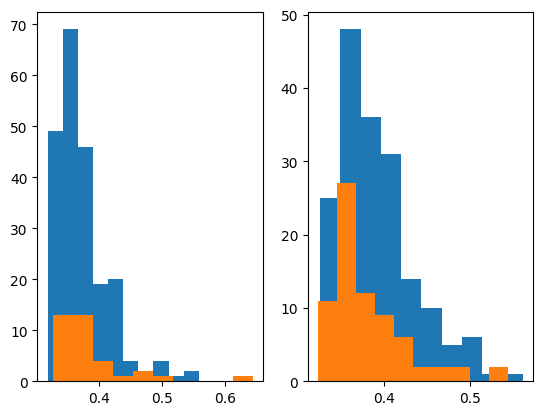

In [9]:
import matplotlib.pyplot as plt

rt = test_data[:, 0]
resp = test_data[:, 1]
cond = test_data[:, 2]

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.hist(rt[jnp.bitwise_and(resp == 1, cond == 1)])
ax1.hist(rt[jnp.bitwise_and(resp == 0, cond == 1)])

ax2.hist(rt[jnp.bitwise_and(resp == 1, cond == 0)])
ax2.hist(rt[jnp.bitwise_and(resp == 0, cond == 0)])

resp[cond == 1].mean(), resp[cond == 0].mean()

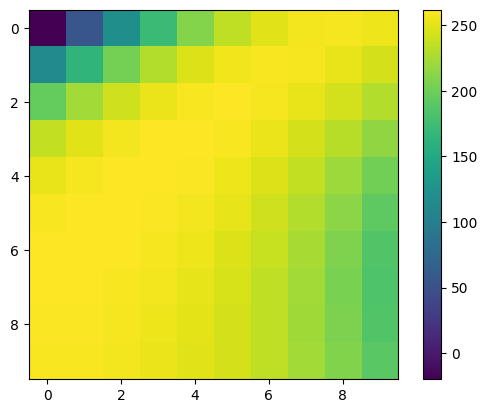

In [10]:
taus = jnp.linspace(0, 1, 10)
amps = jnp.linspace(0, 1, 10)

init_position = jnp.array([1.0, 4.0, 0.1, 0.3, 0.8, 0.7, 0.3])

lls = jnp.zeros((taus.shape[0], amps.shape[0]))

for i, tau in enumerate(taus):
    for j, amp in enumerate(amps):
        init = init_position.at[2].set(amp)
        init = init.at[3].set(tau)
        lls = lls.at[i, j].set(jnp.sum(crdm_likelihood(jnp.log(init))))

plt.imshow(lls)

plt.colorbar();

In [11]:
taus[jnp.where(lls == jnp.max(lls))[0]], amps[jnp.where(lls == jnp.max(lls))[1]]

(Array([0.5555556], dtype=float32), Array([0.22222222], dtype=float32))

In [12]:
@jax.jit
def crdm_prior(x):
    def scale_logtruncnorm(x, loc, scale, a):
        return stats.truncnorm.logpdf(x, loc=loc, scale=scale, a=(a - loc) / scale, b=jnp.inf)

    x = jnp.exp(x)
    v_intercept = scale_logtruncnorm(x[0], 1.0, 0.5, 0.0)
    v_slope = scale_logtruncnorm(x[1], 4.0, 0.5, 0.0)
    amp = scale_logtruncnorm(x[2], 0.3, 0.05, 0.0)
    tau = scale_logtruncnorm(x[3], 0.1, 0.05, 0.0)
    s_true = scale_logtruncnorm(x[4], 1.0, 0.25, 0.0)
    b = stats.gamma.logpdf(x[5], a=4.0, scale=0.15)
    t0 = scale_logtruncnorm(x[6], 0.3, 0.2, 0.0)

    return v_intercept + v_slope + amp + tau + s_true + b + t0

# @nnx.jit
def logdensity_fun(x):
    return crdm_prior(x) + jnp.sum(crdm_likelihood(x))

In [13]:
ll = crdm_likelihood(jnp.log(init_position))

ll[cond == 1].sum(), ll[cond == 0].sum()

(Array(73.70326, dtype=float32), Array(168.47491, dtype=float32))

In [14]:
init_position = jnp.array([1.0, 4.0, 0.5, 0.3, 0.7, 0.5, 0.3])
logdensity_fun(jnp.log(init_position))

Array(326.43973, dtype=float32)

In [15]:
jax.grad(logdensity_fun)(jnp.log(init_position))

Array([ -14.317246,  -72.7344  , -129.00673 ,  -56.7717  ,  109.274254,
        122.273964, 2517.682   ], dtype=float32)

In [16]:
rng_key = jax.random.key(2025)

rng_key, warmup_key = jax.random.split(rng_key)

kernel, last_state, warmup_parameters = warmup(
    blackjax.nuts,
    logdensity_fun,
    jnp.log(init_position),
    1000,
    warmup_key,
    progress_bar=True,
)

Running window adaptation


In [17]:
jnp.exp(last_state.position)

Array([1.0023587 , 3.9963353 , 0.49930626, 0.3003866 , 0.7025573 ,
       0.50098866, 0.29916143], dtype=float32)

In [18]:
num_chains = 4

last_states = jax.vmap(lambda x: last_state)(jnp.arange(num_chains))

trace = inference_loop_multiple_chains(
    rng_key, kernel, last_states, 500, num_chains,
)

samples = jnp.moveaxis(jnp.asarray(jnp.exp(trace.position)), (0, 1, 2), (2, 1, 0))
samples.block_until_ready()

KeyboardInterrupt: 

In [ ]:
blackjax.diagnostics.potential_scale_reduction(trace.position)

Array([0.9942199, 0.9995018, 1.0069051, 1.099365 , 1.0137506, 1.0045384,
       1.006797 ], dtype=float32)

/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


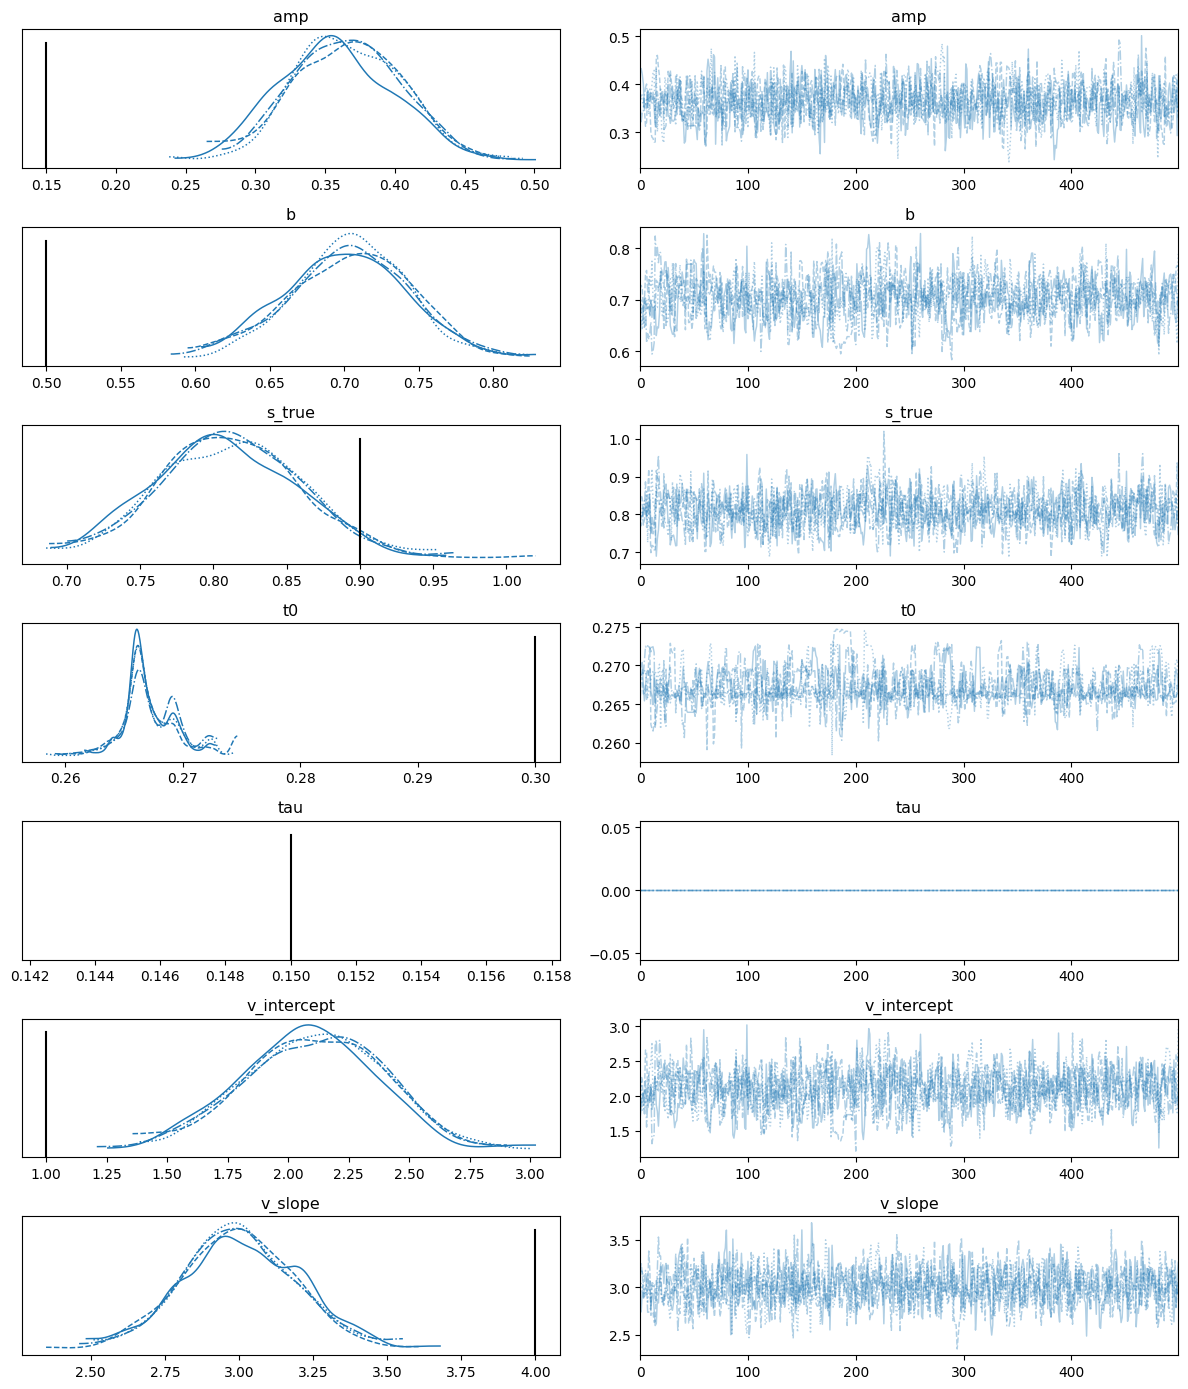

In [ ]:
param_names = ["v_intercept", "v_slope", "amp", "tau", "s_true", "b", "t0"]

idata = az.from_dict(
    posterior={k: v
               for k, v in zip(param_names, samples)})
ax = az.plot_trace(idata)

for i, p in enumerate(sorted(prior_draws)):
    ax[i, 0].axvline(prior_draws[p][0], 0, 0.9, color="k")

plt.tight_layout()